# Credit Risk Decision Engine — Exploratory Data Analysis

This notebook explores the Home Credit Default Risk dataset before feature engineering and model development.

### Objectives

- Understand dataset structure
- Analyze the target variable
- Identify missing values
- Inspect numerical and categorical features
- Detect suspicious or anomalous values
- Identify potential credit-risk signals
- Determine preprocessing and feature-engineering requirements

Imports and project setup

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

#Find Project Root
PROJECT_ROOT=Path.cwd()

if PROJECT_ROOT.name=="notebooks":
    PROJECT_ROOT=PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns",150)
pd.set_option("display.max_rows",100)

PROJECT_ROOT


WindowsPath('d:/Credit-Risk-Decision-Engine')

Load data

In [2]:
from src.components.data_loader import load_training_data

df=load_training_data()

print("Dataset Loaded Successfully")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset Loaded Successfully
Rows: 307,511
Columns: 122


In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Basic structure

In [4]:
df.shape

(307511, 122)

In [7]:
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB


Check duplicate applicants

In [8]:
duplicate_rows=df.duplicated().sum()

duplicate_ids=df["SK_ID_CURR"].duplicated().sum()
print(f"Duplicate Rows: {duplicate_rows}")
print(f"Duplicate IDS: {duplicate_ids}")

Duplicate Rows: 0
Duplicate IDS: 0


This matters because SK_ID_CURR should uniquely identify each applicant.

Understand the target

In [11]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [12]:
target_distribution = (
    df["TARGET"].value_counts(normalize=True).
    mul(100).
    round(2)
)

target_distribution

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

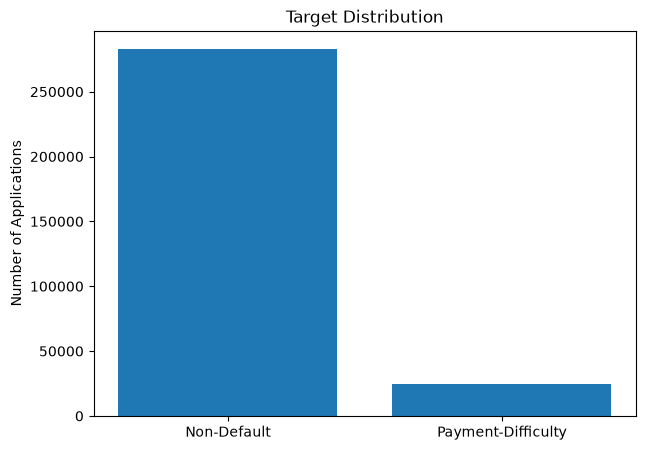

In [14]:
target_counts=df["TARGET"].value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.bar(
    ["Non-Default","Payment-Difficulty"],
    target_counts.values
)
plt.title("Target Distribution")
plt.ylabel("Number of Applications")

plt.show()

Business Interpretation

In [15]:
default_rate=df["TARGET"].mean()*100

print(f"Default/payment difficulty rate: {default_rate:.2f}%")

Default/payment difficulty rate: 8.07%


Separate numerical and categorical columns

In [16]:
numeric_columns= (
    df.select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_columns=(
    df.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print(f"Numerical Columns: {len(numeric_columns)}")
print(f"Categorical Columns: {len(categorical_columns)}")

Numerical Columns: 106
Categorical Columns: 16


In [17]:
categorical_columns

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [18]:
df[categorical_columns].nunique().sort_values()

NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FONDKAPREMONT_MODE             4
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
WEEKDAY_APPR_PROCESS_START     7
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
NAME_INCOME_TYPE               8
OCCUPATION_TYPE               18
ORGANIZATION_TYPE             58
dtype: int64

Missing values

In [21]:
missing_values=(
    df.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_values.head(25)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
BASEMENTAREA_MODE           58.515956
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
dtype: float64

Turn it into a Cleaner Table

In [22]:
missing_summary=pd.DataFrame({
    "missing_counts": df.isnull().sum(),
    "missing_percentages": df.isnull().mean()*100
})

missing_summary=(
    missing_summary
    .query("missing_counts>0")
    .sort_values(
        "missing_percentages",
        ascending=False
    )
)

missing_summary.head(30)

,missing_counts,missing_percentages
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [24]:
print("Columns with >50% missing data:",
(missing_summary["missing_percentages"]>50).sum())

print("Columns with >30% missing data:",
(missing_summary["missing_percentages"]>30).sum())

Columns with >50% missing data: 41
Columns with >30% missing data: 50


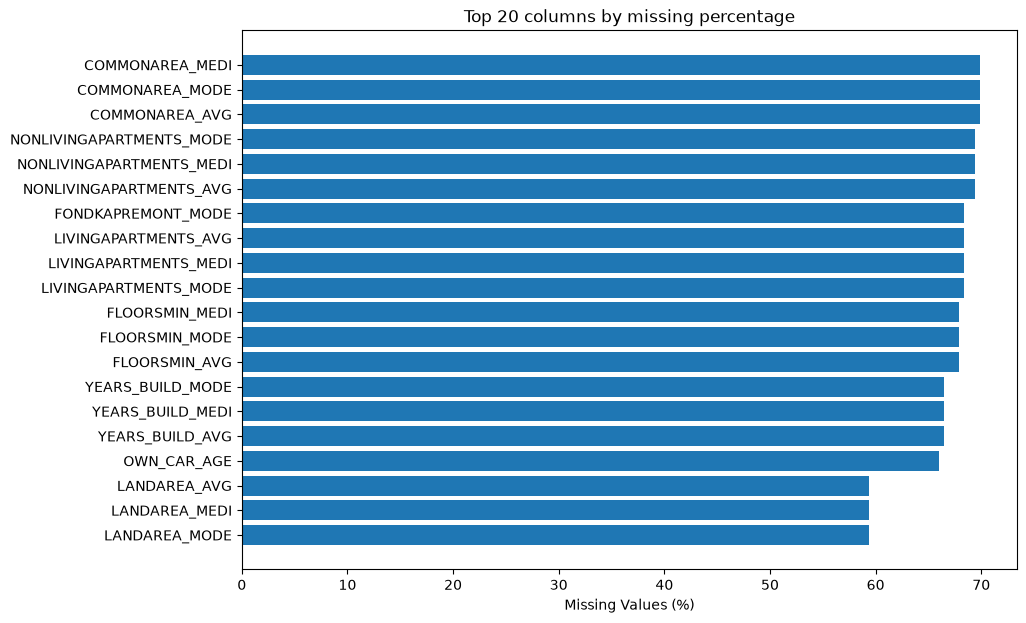

In [26]:
top_missing=missing_summary.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top_missing.index[::-1],
    top_missing["missing_percentages"][::-1]
)
plt.xlabel("Missing Values (%)")
plt.title("Top 20 columns by missing percentage")

plt.show()

Numerical summary

In [27]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [28]:
important_numeric_columns = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
]

df[important_numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0


Investigate DAYS_BIRTH

Home Credit represents dates relative to the application date using negative day values.

In [29]:
df["DAYS_BIRTH"].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

In [30]:
age_years = -df["DAYS_BIRTH"] / 365.25

age_years.describe()

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: DAYS_BIRTH, dtype: float64

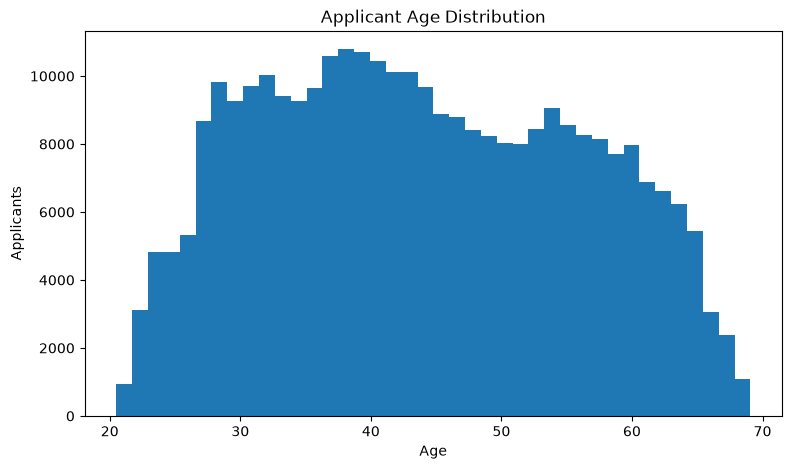

In [33]:
plt.figure(figsize=(9, 5))

plt.hist(
    age_years,
    bins=40,
    )

plt.xlabel("Age")
plt.ylabel("Applicants")
plt.title("Applicant Age Distribution")

plt.show()

We are not modifying df yet. We're just learning what transformation will later make sense.

Investigate DAYS_EMPLOYED

In [34]:
df["DAYS_EMPLOYED"].value_counts().head(10)

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
-212         150
-229         143
-384         143
-231         140
-215         138
Name: count, dtype: int64

In [35]:
anomalous_employment = (
    df["DAYS_EMPLOYED"] == 365243
).sum()

print(
    f"Applicants with DAYS_EMPLOYED = 365243: "
    f"{anomalous_employment:,}"
)

Applicants with DAYS_EMPLOYED = 365243: 55,374


In [36]:
print(
    f"Percentage: "
    f"{anomalous_employment / len(df) * 100:.2f}%"
)

Percentage: 18.01%


## Initial EDA Findings

1. The target variable is highly imbalanced, so accuracy will not be an appropriate primary evaluation metric.

2. The dataset contains a mixture of numerical and categorical features and will require separate preprocessing strategies.

3. Several columns contain substantial missing values. Their predictive value should be evaluated before deciding whether to drop them.

4. `DAYS_BIRTH` is stored as negative days and can be transformed into applicant age in years.

5. `DAYS_EMPLOYED` contains a suspicious value of `365243`, which should be treated as an anomalous/missing value during preprocessing.

6. Applicant ID (`SK_ID_CURR`) should be excluded from modelling because it is an identifier rather than a predictive feature.

## Relationship Between Financial Features and Default Risk

The following analysis compares important financial variables across customers with and without payment difficulties.

In [37]:
income = df["AMT_INCOME_TOTAL"]

income.describe(percentiles=[0.90, 0.95, 0.99])

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
90%      2.700000e+05
95%      3.375000e+05
99%      4.725000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [38]:
df.nlargest(
    10,
    "AMT_INCOME_TOTAL"
)[
    [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "TARGET"
    ]
]

,AMT_INCOME_TOTAL,AMT_CREDIT,TARGET
12840,117000000.0,562491.0,1
203693,18000090.0,675000.0,0
246858,13500000.0,1400503.5,0
77768,9000000.0,1431531.0,0
131127,6750000.0,790830.0,0
103006,4500000.0,2250000.0,0
187833,4500000.0,835380.0,0
204564,4500000.0,450000.0,0
287463,4500000.0,1755000.0,0
181698,3950059.5,675000.0,0


Instead of plotting the extreme tail, temporarily restrict visualization to the 99th percentile:

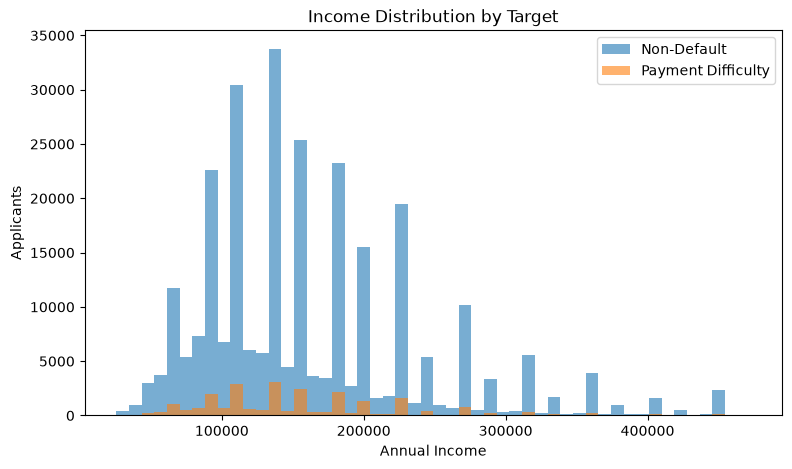

In [39]:
income_99 = df[
    df["AMT_INCOME_TOTAL"]
    <= df["AMT_INCOME_TOTAL"].quantile(0.99)
]

plt.figure(figsize=(9, 5))

plt.hist(
    income_99.loc[
        income_99["TARGET"] == 0,
        "AMT_INCOME_TOTAL"
    ],
    bins=50,
    alpha=0.6,
    label="Non-Default"
)

plt.hist(
    income_99.loc[
        income_99["TARGET"] == 1,
        "AMT_INCOME_TOTAL"
    ],
    bins=50,
    alpha=0.6,
    label="Payment Difficulty"
)

plt.xlabel("Annual Income")
plt.ylabel("Applicants")
plt.title("Income Distribution by Target")
plt.legend()

plt.show()

In [40]:
df.groupby("TARGET")[
    "AMT_CREDIT"
].median()

TARGET
0    517788.0
1    497520.0
Name: AMT_CREDIT, dtype: float64

<Figure size 800x500 with 0 Axes>

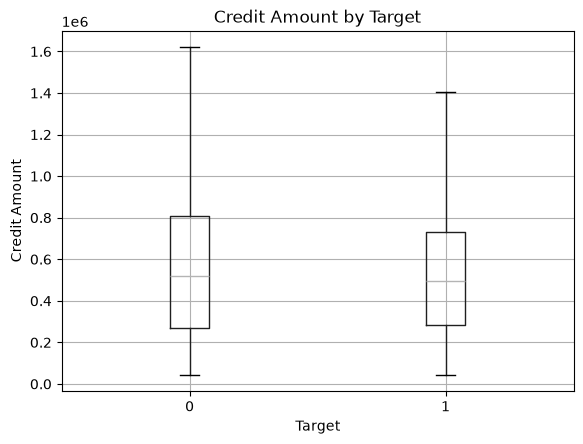

In [41]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="AMT_CREDIT",
    by="TARGET",
    showfliers=False
)

plt.title("Credit Amount by Target")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Credit Amount")

plt.show()

0 = No payment difficulty
1 = Payment difficulty

Create temporary financial ratios for EDA

Do not modify the raw dataframe permanently.

In [42]:
eda_df = df.copy()

In [43]:
eda_df["CREDIT_INCOME_RATIO"] = (
    eda_df["AMT_CREDIT"]
    / eda_df["AMT_INCOME_TOTAL"]
)

eda_df["ANNUITY_INCOME_RATIO"] = (
    eda_df["AMT_ANNUITY"]
    / eda_df["AMT_INCOME_TOTAL"]
)

eda_df["CREDIT_TERM"] = (
    eda_df["AMT_CREDIT"]
    / eda_df["AMT_ANNUITY"]
)

Remove infinities

In [45]:
eda_df = eda_df.replace(
    [np.inf, -np.inf],
    np.nan
)

Compare the medians

In [46]:
eda_df.groupby("TARGET")[
    [
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "CREDIT_TERM"
    ]
].median()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM
TARGET,,,
0,3.266653,0.162280,20.0
1,3.253143,0.169294,20.0


Age vs default risk

In [47]:
eda_df["AGE_YEARS"] = (
    -eda_df["DAYS_BIRTH"] / 365.25
)

In [48]:
eda_df.groupby("TARGET")[
    "AGE_YEARS"
].mean()

TARGET
0    44.183919
1    40.752438
Name: AGE_YEARS, dtype: float64

Divide applicants into age groups

In [49]:
eda_df["AGE_GROUP"] = pd.cut(
    eda_df["AGE_YEARS"],
    bins=[
        20,
        30,
        40,
        50,
        60,
        70
    ],
    labels=[
        "20-30",
        "30-40",
        "40-50",
        "50-60",
        "60-70"
    ]
)

Calculate default rate

In [50]:
age_default_rate = (
    eda_df
    .groupby(
        "AGE_GROUP",
        observed=False
    )["TARGET"]
    .mean()
    .mul(100)
)

age_default_rate

AGE_GROUP
20-30    11.443810
30-40     9.589673
40-50     7.642888
50-60     6.119602
60-70     4.919798
Name: TARGET, dtype: float64

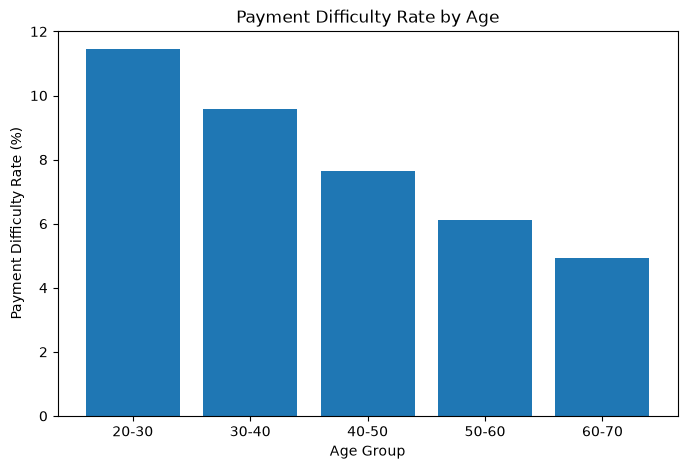

In [51]:
plt.figure(figsize=(8, 5))

plt.bar(
    age_default_rate.index.astype(str),
    age_default_rate.values
)

plt.xlabel("Age Group")
plt.ylabel("Payment Difficulty Rate (%)")
plt.title("Payment Difficulty Rate by Age")

plt.show()

This may reveal a much stronger relationship than simply looking at DAYS_BIRTH

Employment history

For EDA only

In [52]:
eda_df["DAYS_EMPLOYED_CLEAN"] = (
    eda_df["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
)

In [53]:
eda_df["EMPLOYMENT_YEARS"] = (
    -eda_df["DAYS_EMPLOYED_CLEAN"]
    / 365.25
)

In [54]:
eda_df.groupby("TARGET")[
    "EMPLOYMENT_YEARS"
].median()

TARGET
0    4.629706
1    3.367556
Name: EMPLOYMENT_YEARS, dtype: float64

Potential feature

In [55]:
eda_df["EMPLOYMENT_AGE_RATIO"] = (
    eda_df["EMPLOYMENT_YEARS"]
    / eda_df["AGE_YEARS"]
)

In [56]:
eda_df.groupby("TARGET")[
    "EMPLOYMENT_AGE_RATIO"
].median()

TARGET
0    0.121592
1    0.093461
Name: EMPLOYMENT_AGE_RATIO, dtype: float64

Contract type

In [57]:
df["NAME_CONTRACT_TYPE"].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

Default rates

In [58]:
contract_default_rate = (
    df
    .groupby("NAME_CONTRACT_TYPE")[
        "TARGET"
    ]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

contract_default_rate

NAME_CONTRACT_TYPE
Cash loans         8.345913
Revolving loans    5.478329
Name: TARGET, dtype: float64

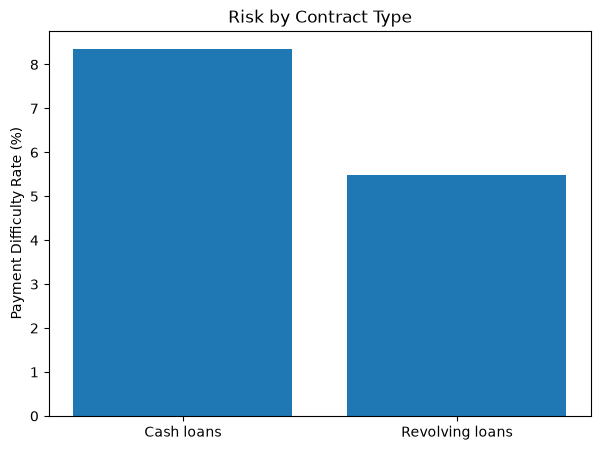

In [59]:
plt.figure(figsize=(7, 5))

plt.bar(
    contract_default_rate.index,
    contract_default_rate.values
)

plt.ylabel("Payment Difficulty Rate (%)")
plt.title("Risk by Contract Type")

plt.show()

Education and default risk

In [60]:
education_risk = (
    df
    .groupby(
        "NAME_EDUCATION_TYPE"
    )["TARGET"]
    .agg(
        default_rate="mean",
        applicants="count"
    )
)

education_risk["default_rate"] *= 100

education_risk.sort_values(
    "default_rate",
    ascending=False
)

,default_rate,applicants
NAME_EDUCATION_TYPE,,
Lower secondary,10.927673,3816
Secondary / secondary special,8.939929,218391
Incomplete higher,8.484966,10277
Higher education,5.355115,74863
Academic degree,1.829268,164


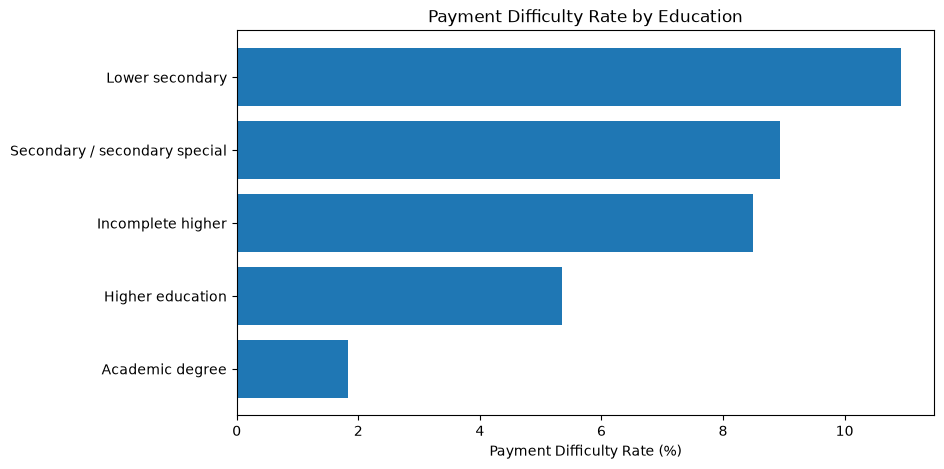

In [63]:
education_plot = (
    education_risk
    .sort_values(
        "default_rate",
        ascending=True
    )
)

plt.figure(figsize=(9, 5))

plt.barh(
    education_plot.index,
    education_plot["default_rate"]
)

plt.xlabel("Payment Difficulty Rate (%)")
plt.title("Payment Difficulty Rate by Education")

plt.show()

Income type

In [64]:
income_type_risk = (
    df
    .groupby(
        "NAME_INCOME_TYPE"
    )["TARGET"]
    .agg(
        default_rate="mean",
        applicants="count"
    )
)

income_type_risk["default_rate"] *= 100

income_type_risk.sort_values(
    "default_rate",
    ascending=False
)

,default_rate,applicants
NAME_INCOME_TYPE,,
Maternity leave,40.000000,5
Unemployed,36.363636,22
Working,9.588472,158774
Commercial associate,7.484257,71617
State servant,5.754965,21703
Pensioner,5.386366,55362
Businessman,0.000000,10
Student,0.000000,18


Occupation risk

In [65]:
occupation_risk = (
    df
    .groupby("OCCUPATION_TYPE")[
        "TARGET"
    ]
    .agg(
        default_rate="mean",
        applicants="count"
    )
)

occupation_risk["default_rate"] *= 100

Only show reasonably populated occupations:

In [66]:
occupation_risk_filtered = (
    occupation_risk[
        occupation_risk["applicants"]
        >= 1000
    ]
    .sort_values(
        "default_rate",
        ascending=False
    )
)

occupation_risk_filtered

,default_rate,applicants
OCCUPATION_TYPE,,
Low-skill Laborers,17.152413,2093
Drivers,11.326130,18603
Waiters/barmen staff,11.275964,1348
Security staff,10.742449,6721
Laborers,10.578770,55186
Cooking staff,10.443996,5946
Sales staff,9.631799,32102
Cleaning staff,9.606705,4653
Secretaries,7.049808,1305


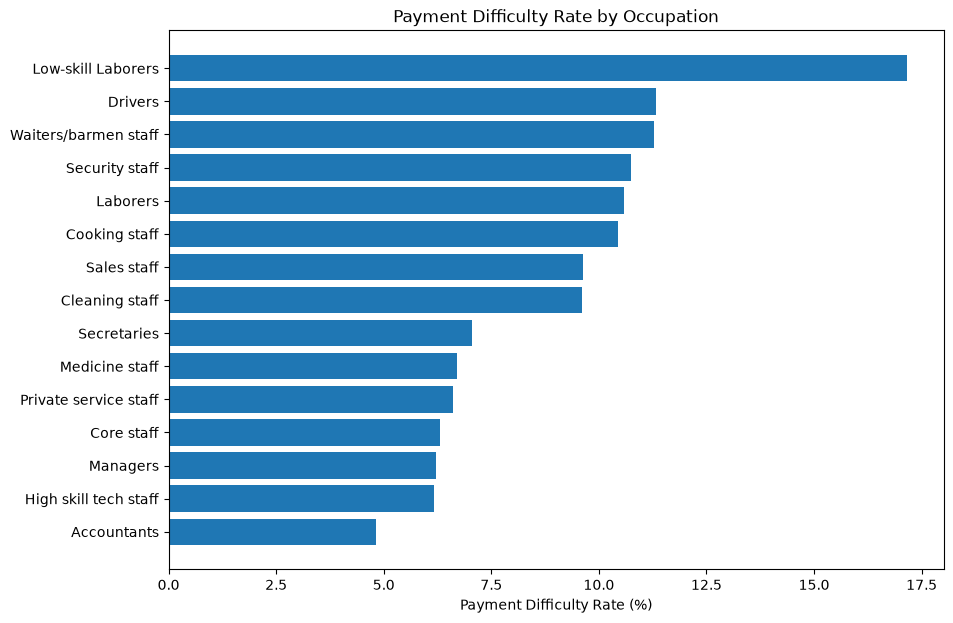

In [67]:
plt.figure(figsize=(10, 7))

plt.barh(
    occupation_risk_filtered.index[::-1],
    occupation_risk_filtered[
        "default_rate"
    ][::-1]
)

plt.xlabel("Payment Difficulty Rate (%)")
plt.title(
    "Payment Difficulty Rate by Occupation"
)

plt.show()

Family status

In [68]:
family_risk = (
    df
    .groupby(
        "NAME_FAMILY_STATUS"
    )["TARGET"]
    .mean()
    .mul(100)
    .sort_values(
        ascending=False
    )
)

family_risk

NAME_FAMILY_STATUS
Civil marriage          9.944584
Single / not married    9.807675
Separated               8.194234
Married                 7.559868
Widow                   5.824217
Unknown                 0.000000
Name: TARGET, dtype: float64

Also check children

In [69]:
children_risk = (
    df
    .groupby(
        "CNT_CHILDREN"
    )["TARGET"]
    .agg(
        default_rate="mean",
        applicants="count"
    )
)

children_risk[
    "default_rate"
] *= 100

children_risk.head(10)

,default_rate,applicants
CNT_CHILDREN,,
0,7.711809,215371
1,8.923575,61119
2,8.721821,26749
3,9.631423,3717
4,12.820513,429
5,8.333333,84
6,28.571429,21
7,0.000000,7
8,0.000000,2


Housing type

In [71]:
housing_risk = (
    df
    .groupby(
        "NAME_HOUSING_TYPE"
    )["TARGET"]
    .agg(
        default_rate="mean",
        applicants="count"
    )
)

housing_risk["default_rate"] *= 100

housing_risk.sort_values(
    "default_rate",
    ascending=False
)

,default_rate,applicants
NAME_HOUSING_TYPE,,
Rented apartment,12.313051,4881
With parents,11.698113,14840
Municipal apartment,8.539748,11183
Co-op apartment,7.932264,1122
House / apartment,7.795711,272868
Office apartment,6.572411,2617


External credit scores

In [72]:
external_columns = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

df[
    external_columns
    + ["TARGET"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,0.962693
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,0.855000
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,0.896010
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000


In [73]:
df.groupby("TARGET")[
    external_columns
].mean()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,,,
0,0.511461,0.523479,0.520969
1,0.386968,0.410935,0.390717


Plot each separately

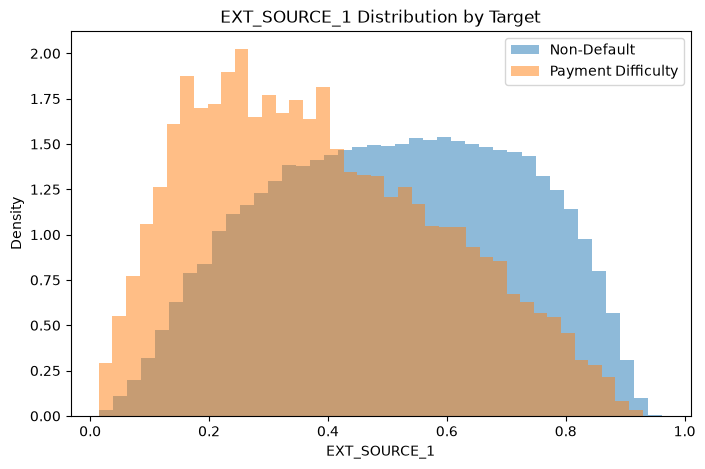

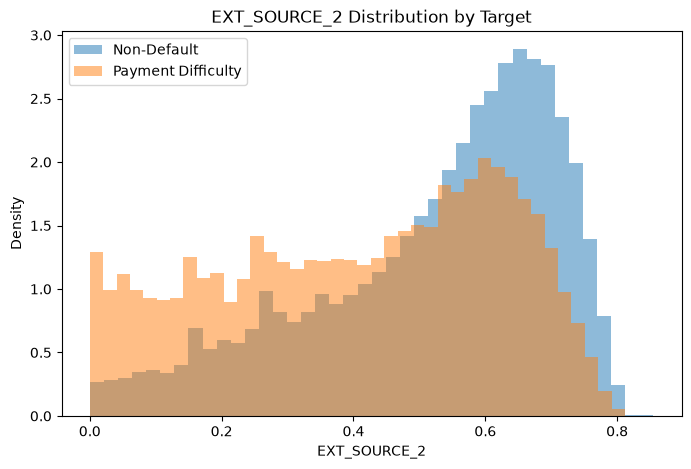

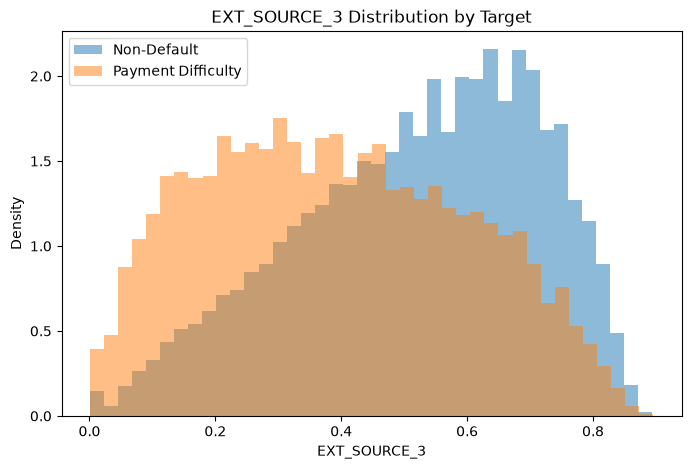

In [74]:
for column in external_columns:

    plt.figure(figsize=(8, 5))

    non_default = df.loc[
        df["TARGET"] == 0,
        column
    ].dropna()

    default = df.loc[
        df["TARGET"] == 1,
        column
    ].dropna()

    plt.hist(
        non_default,
        bins=40,
        alpha=0.5,
        density=True,
        label="Non-Default"
    )

    plt.hist(
        default,
        bins=40,
        alpha=0.5,
        density=True,
        label="Payment Difficulty"
    )

    plt.title(
        f"{column} Distribution by Target"
    )

    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()

    plt.show()

Combine external scores experimentally

In [75]:
eda_df[
    "EXT_SOURCE_MEAN"
] = (
    eda_df[
        external_columns
    ]
    .mean(axis=1)
)

In [76]:
eda_df.groupby("TARGET")[
    "EXT_SOURCE_MEAN"
].mean()

TARGET
0    0.519109
1    0.397003
Name: EXT_SOURCE_MEAN, dtype: float64

Numeric correlation with target

In [77]:
numeric_df = df.select_dtypes(
    include=np.number
)

target_correlations = (
    numeric_df
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values()
)

Most negative

In [78]:
target_correlations.head(15)

EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
ELEVATORS_MEDI               -0.033863
FLOORSMIN_AVG                -0.033614
FLOORSMIN_MEDI               -0.033394
LIVINGAREA_AVG               -0.032997
LIVINGAREA_MEDI              -0.032739
Name: TARGET, dtype: float64

Most positive

In [79]:
target_correlations.tail(15)

FLAG_WORK_PHONE                0.028524
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64

Create a combined table

In [80]:
important_correlations = pd.concat(
    [
        target_correlations.head(10),
        target_correlations.tail(10)
    ]
)

important_correlations

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_EMPLOYED                 -0.044932
FLOORSMAX_AVG                 -0.044003
FLOORSMAX_MEDI                -0.043768
FLOORSMAX_MODE                -0.043226
AMT_GOODS_PRICE               -0.039645
REGION_POPULATION_RELATIVE    -0.037227
ELEVATORS_AVG                 -0.034199
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64

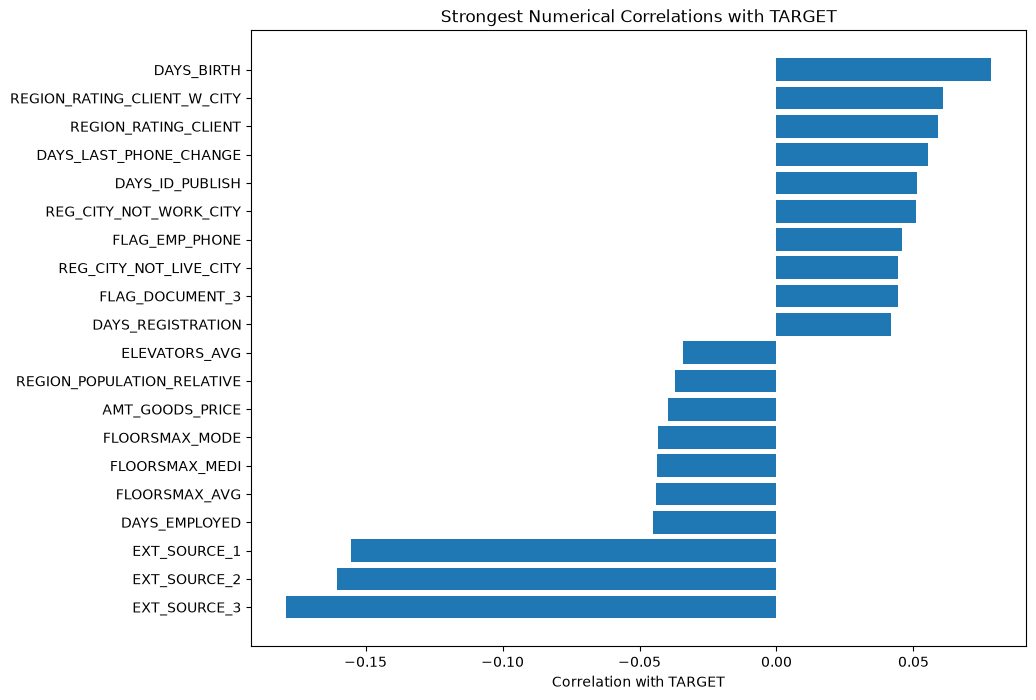

In [81]:
plt.figure(figsize=(10, 8))

plt.barh(
    important_correlations.index,
    important_correlations.values
)

plt.xlabel("Correlation with TARGET")
plt.title(
    "Strongest Numerical Correlations with TARGET"
)

plt.show()

Identify very highly correlated predictors

Remove TARGET and ID

In [82]:
features_for_corr = (
    numeric_df
    .drop(
        columns=[
            "TARGET",
            "SK_ID_CURR"
        ],
        errors="ignore"
    )
)

Correlation matrix

In [83]:
corr_matrix = (
    features_for_corr
    .corr()
    .abs()
)

Upper triangle

In [84]:
upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(
            corr_matrix.shape
        ),
        k=1
    ).astype(bool)
)

Find > 0.90 correlations

In [85]:
highly_correlated = []

for column in upper_triangle.columns:

    matches = (
        upper_triangle[column][
            upper_triangle[column] > 0.90
        ]
    )

    for feature, correlation in matches.items():

        highly_correlated.append(
            (
                feature,
                column,
                correlation
            )
        )

View

In [86]:
pd.DataFrame(
    highly_correlated,
    columns=[
        "feature_1",
        "feature_2",
        "correlation"
    ]
).sort_values(
    "correlation",
    ascending=False
).head(30)

,feature_1,feature_2,correlation
1,DAYS_EMPLOYED,FLAG_EMP_PHONE,0.999755
32,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998495
61,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998490
42,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997241
40,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997034
38,ENTRANCES_AVG,ENTRANCES_MEDI,0.996886
36,ELEVATORS_AVG,ELEVATORS_MEDI,0.996099
34,COMMONAREA_AVG,COMMONAREA_MEDI,0.995978
52,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.995596
23,APARTMENTS_AVG,APARTMENTS_MEDI,0.995081


We're not dropping them yet.

For Logistic Regression, multicollinearity matters more.

For XGBoost, it is usually less problematic.

Check categorical cardinality

In [87]:
categorical_cardinality = (
    df[
        categorical_columns
    ]
    .nunique()
    .sort_values(
        ascending=False
    )
)

categorical_cardinality

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64

In [88]:
categorical_cardinality[
    categorical_cardinality > 20
]

ORGANIZATION_TYPE    58
dtype: int64

Check suspicious numeric values

In [89]:
checks = {
    "Negative income": (
        df["AMT_INCOME_TOTAL"] < 0
    ).sum(),

    "Zero income": (
        df["AMT_INCOME_TOTAL"] == 0
    ).sum(),

    "Negative credit": (
        df["AMT_CREDIT"] < 0
    ).sum(),

    "Zero credit": (
        df["AMT_CREDIT"] == 0
    ).sum(),

    "Positive DAYS_BIRTH": (
        df["DAYS_BIRTH"] > 0
    ).sum(),

    "DAYS_EMPLOYED anomaly": (
        df["DAYS_EMPLOYED"] == 365243
    ).sum(),
}

pd.Series(checks)

Negative income              0
Zero income                  0
Negative credit              0
Zero credit                  0
Positive DAYS_BIRTH          0
DAYS_EMPLOYED anomaly    55374
dtype: int64

Find extreme outliers

In [90]:
outlier_columns = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "CNT_CHILDREN"
]

In [91]:
for column in outlier_columns:

    print(
        f"\n{column}"
    )

    print(
        df[column].quantile(
            [
                0.50,
                0.90,
                0.95,
                0.99,
                0.999
            ]
        )
    )


AMT_INCOME_TOTAL
0.500    147150.0
0.900    270000.0
0.950    337500.0
0.990    472500.0
0.999    900000.0
Name: AMT_INCOME_TOTAL, dtype: float64

AMT_CREDIT
0.500     513531.0
0.900    1133748.0
0.950    1350000.0
0.990    1854000.0
0.999    2517300.0
Name: AMT_CREDIT, dtype: float64

AMT_ANNUITY
0.500     24903.0
0.900     45954.0
0.950     53325.0
0.990     70006.5
0.999    110047.5
Name: AMT_ANNUITY, dtype: float64

CNT_CHILDREN
0.500    0.0
0.900    2.0
0.950    2.0
0.990    3.0
0.999    4.0
Name: CNT_CHILDREN, dtype: float64


Build preliminary feature shortlist

## Preliminary Candidate Features

Based on the exploratory analysis, the following engineered features appear worth testing:

### Applicant characteristics

- `AGE_YEARS`
- `EMPLOYMENT_YEARS`
- `EMPLOYMENT_AGE_RATIO`

### Affordability

- `CREDIT_INCOME_RATIO`
- `ANNUITY_INCOME_RATIO`
- `CREDIT_TERM`

### Household

- Income per family member
- Credit amount per family member

### External credit information

- Mean external score
- Minimum external score
- Maximum external score
- Standard deviation of external scores

These features are hypotheses only and will be validated through model performance in the feature-engineering notebook.

Record modelling implications

## Modelling Implications From EDA

### 1. Class imbalance

The positive class represents a relatively small proportion of applicants.

Therefore:

- Accuracy should not be the primary metric.
- ROC-AUC and PR-AUC should be evaluated.
- Recall and precision for risky applicants are important.
- Class weighting may be tested.

### 2. Missing values

Several potentially useful features contain substantial missing data.

The first modelling approach will test imputation rather than immediately dropping these variables.

### 3. Mixed feature types

The dataset contains both numerical and categorical variables.

Different preprocessing pipelines will therefore be required.

### 4. Anomalous employment values

`DAYS_EMPLOYED = 365243` appears to represent a special/anomalous value and should be handled during preprocessing.

### 5. External credit scores

`EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` appear strongly related to payment difficulty and should be retained.

### 6. Derived affordability features

Credit-to-income and annuity-to-income ratios may better represent financial burden than raw monetary values alone.

### 7. Outliers

Several financial variables are heavily skewed and contain extreme observations.

Tree-based models may naturally handle these distributions better than linear models, while Logistic Regression may benefit from transformations and scaling.

End the notebook with a summary table

In [92]:
eda_summary = pd.DataFrame(
    {
        "Area": [
            "Target",
            "Missingness",
            "Employment",
            "Age",
            "External Scores",
            "Affordability",
            "Categorical Features",
            "Outliers"
        ],

        "Finding": [
            "Strong class imbalance",
            "Several columns have substantial missing values",
            "DAYS_EMPLOYED contains anomalous value 365243",
            "Default behaviour varies across age groups",
            "EXT_SOURCE variables show strong risk signal",
            "Credit/income and annuity/income ratios are promising",
            "Multiple categorical variables show differing risk rates",
            "Financial variables contain heavily skewed observations"
        ],

        "Next Step": [
            "Use ROC-AUC, PR-AUC, recall and precision",
            "Test robust imputation strategies",
            "Replace anomaly before modelling",
            "Engineer AGE_YEARS",
            "Retain and aggregate external scores",
            "Engineer affordability ratios",
            "Encode categorical variables",
            "Compare linear and tree-based modelling"
        ]
    }
)

eda_summary

,Area,Finding,Next Step
0,Target,Strong class imbalance,"Use ROC-AUC, PR-AUC, recall and precision"
1,Missingness,Several columns have substantial missing values,Test robust imputation strategies
2,Employment,DAYS_EMPLOYED contains anomalous value 365243,Replace anomaly before modelling
3,Age,Default behaviour varies across age groups,Engineer AGE_YEARS
4,External Scores,EXT_SOURCE variables show strong risk signal,Retain and aggregate external scores
5,Affordability,Credit/income and annuity/income ratios are pr...,Engineer affordability ratios
6,Categorical Features,Multiple categorical variables show differing ...,Encode categorical variables
7,Outliers,Financial variables contain heavily skewed obs...,Compare linear and tree-based modelling
